In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import joblib
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [4]:
df_short = pd.read_csv('../../../tsfel_features_short_new.csv')
df_long = pd.read_csv('../../../tsfel_features_long_new.csv')
df_full = pd.read_csv('../../../tsfel_features_full_new.csv')

In [5]:
common_features_short_df = pd.read_csv('../../../common_features_short_new.csv')
common_features_long_df = pd.read_csv('../../../common_features_long_new.csv')
common_features_full_df = pd.read_csv('../../../common_features_full_new.csv')

In [6]:
selected_short_features = common_features_short_df['feature'].tolist()
selected_long_features = common_features_long_df['feature'].tolist()
selected_full_features = common_features_full_df['feature'].tolist()

In [8]:
def add_gaussian_noise(data, mean=0.0, std=0.01):
    noise = np.random.normal(mean, std, data.shape)
    return data + noise

# short

In [9]:
features_short = selected_short_features + ['label']
features_short

['Head_Tilt_2D_Head_Tilt_2D_Max',
 'Shoulder_Line_Angle_2D_Shoulder_Line_Angle_2D_MFCC_4',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_Max',
 'Head_Tilt_2D_Head_Tilt_2D_Average power',
 'Head_Tilt_2D_Head_Tilt_2D_Mean',
 'Head_Tilt_2D_Head_Tilt_2D_Min',
 'Head_Tilt_2D_Head_Tilt_2D_Root mean square',
 'Head_Tilt_2D_Head_Tilt_2D_Median',
 'Head_Tilt_2D_Head_Tilt_2D_ECDF Percentile_1',
 'Neck2D_Neck_Inclination_2D_Max',
 'Head_Tilt_2D_Head_Tilt_2D_Histogram mode',
 'Head_Tilt_2D_Head_Tilt_2D_MFCC_3',
 'Torso2D_Torso_Inclination_2D_MFCC_7',
 'Torso3D_Torso_Inclination_3D_Fundamental frequency',
 'Head_Tilt_2D_Head_Tilt_2D_Autocorrelation',
 'Head_Tilt_3D_Head_Tilt_3D_LPCC_2',
 'Shoulder_Line_Angle_2D_Shoulder_Line_Angle_2D_MFCC_5',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_6',
 'Torso2D_Torso_Inclination_2D_Max',
 'Head_Tilt_2D_Head_Tilt_2D_Absolute energy',
 'Head_Tilt_3D_Head_Tilt_3D_LPCC_4',
 'Neck3D_Neck_Inclination_3D_LPCC_2',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_ECDF Percentile

In [10]:
X_a_short = df_short[selected_short_features]
y_a_short = df_short['label']
name_a_short = df_short['video']

In [11]:
k = 1 
X_aug_list = []
y_aug_list = []

for i in range(k):
    noisy_features = add_gaussian_noise(X_a_short[selected_short_features])
    X_aug_list.append(noisy_features)
    y_aug_list.append(y_a_short)

# Noisy data
X_aug = pd.concat(X_aug_list, ignore_index=True)
y_aug = pd.concat(y_aug_list, ignore_index=True)

# Original + Noisy data concat
X_combined = pd.concat([X_a_short.reset_index(drop=True), X_aug], ignore_index=True)
y_combined = pd.concat([y_a_short.reset_index(drop=True), y_aug], ignore_index=True)

# 3. SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_combined)

# 4. Train-test split (last)
X_train_resampled, X_test_short, y_train_resampled, y_test_short = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

In [12]:
temp_train_resampled_short = X_train_resampled
temp_test_short = X_test_short
temp_train_resampled_short_labels = y_train_resampled
temp_test_short_labels =  y_test_short

In [13]:
print(X_train_resampled.shape)
print(y_train_resampled.shape)

(118, 30)
(118,)


In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [10, 20, 30], 
    'classifier__max_depth': [2, 3, 5], 
    'classifier__min_samples_split': [4, 6, 8], 
    'classifier__min_samples_leaf': [2, 3, 4] 
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_short)
accuracy = accuracy_score(y_test_short, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 20}
Best cross-validation score: 0.9402
Test accuracy: 0.9333


In [15]:
joblib.dump(best_model, 'best_random_forest_model_short.pkl')

['best_random_forest_model_short.pkl']

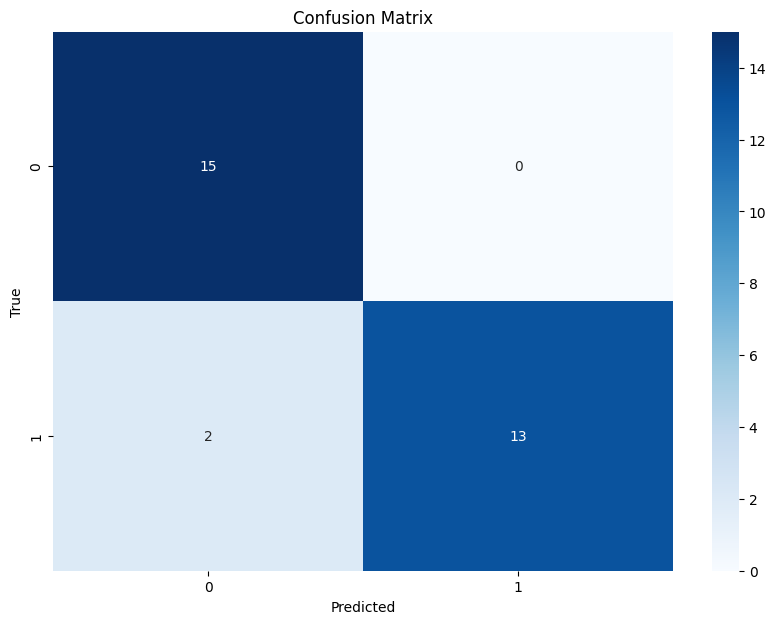

In [16]:
conf_matrix = confusion_matrix(y_test_short, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [17]:
print(classification_report(y_test_short, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8824    1.0000    0.9375        15
           1     1.0000    0.8667    0.9286        15

    accuracy                         0.9333        30
   macro avg     0.9412    0.9333    0.9330        30
weighted avg     0.9412    0.9333    0.9330        30



# long

In [18]:
features_long = selected_long_features + ['label']
features_long

['Head_Tilt_2D_Head_Tilt_2D_Absolute energy',
 'Head_Tilt_2D_Head_Tilt_2D_Slope',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_MFCC_9',
 'Head_Tilt_2D_Head_Tilt_2D_ECDF Percentile_0',
 'Head_Tilt_2D_Head_Tilt_2D_ECDF Percentile_1',
 'Head_Tilt_2D_Head_Tilt_2D_Average power',
 'Neck2D_Neck_Inclination_2D_ECDF Percentile_0',
 'Neck2D_Neck_Inclination_2D_Absolute energy',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_2',
 'Head_Tilt_2D_Head_Tilt_2D_Mean',
 'Torso2D_Torso_Inclination_2D_MFCC_9',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_3',
 'Torso2D_Torso_Inclination_2D_Median absolute deviation',
 'Neck3D_Neck_Inclination_3D_Mean diff',
 'Head_Tilt_2D_Head_Tilt_2D_Spectral distance',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_11',
 'Torso2D_Torso_Inclination_2D_Positive turning points',
 'Torso3D_Torso_Inclination_3D_MFCC_9',
 'Head_Tilt_2D_Head_Tilt_2D_Root mean square',
 'Head_Tilt_3D_Head_Tilt_3D_Mean diff',
 'Shoulder_Line_Angle_2D_Shoulder_Line_Angle_2D_Spectral positive turning points',
 'Head_Tilt_2D_Head_Til

In [19]:
X_a_long = df_long[selected_long_features]
y_a_long = df_long['label']
name_a_long = df_long['video']


In [20]:
# 1. Add Gaussian Noise
k = 1
X_aug_long_list = []
y_aug_long_list = []

for i in range(k):
    noisy_features_long = add_gaussian_noise(X_a_long[selected_long_features])
    X_aug_long_list.append(noisy_features_long)
    y_aug_long_list.append(y_a_long)

# 2. Merge noisy data
X_aug_long = pd.concat(X_aug_long_list, ignore_index=True)
y_aug_long = pd.concat(y_aug_long_list, ignore_index=True)

# 3. Merge original + noisy data
X_combined_long = pd.concat([X_a_long.reset_index(drop=True), X_aug_long], ignore_index=True)
y_combined_long = pd.concat([y_a_long.reset_index(drop=True), y_aug_long], ignore_index=True)

# 4. SMOTE
X_resampled_long, y_resampled_long = SMOTE(random_state=42).fit_resample(X_combined_long, y_combined_long)

# 5. last train-test split
X_train_resampled, X_test_long, y_train_resampled, y_test_long = train_test_split(
    X_resampled_long, y_resampled_long, test_size=0.2, random_state=42, stratify=y_resampled_long
)


In [21]:
print(X_train_resampled.shape)
print(y_train_resampled.shape)

(118, 30)
(118,)


In [22]:
temp_train_resampled_long = X_train_resampled
temp_test_long = X_test_long
temp_train_resampled_long_labels = y_train_resampled
temp_test_long_labels = y_test_long

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [10, 20, 30], 
    'classifier__max_depth': [2, 3, 5],  
    'classifier__min_samples_split': [4, 6, 8], 
    'classifier__min_samples_leaf': [2, 3, 4]  
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_long)
accuracy = accuracy_score(y_test_long, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")


Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 6, 'classifier__n_estimators': 30}
Best cross-validation score: 0.9235
Test accuracy: 0.8667


In [24]:
joblib.dump(best_model, 'best_random_forest_model_long.pkl')

['best_random_forest_model_long.pkl']

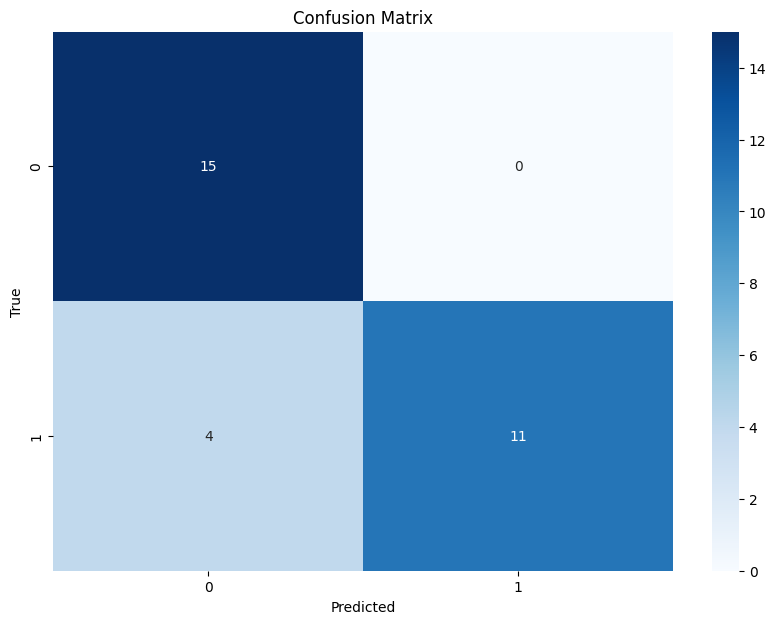

In [25]:
conf_matrix = confusion_matrix(y_test_long, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [26]:
print(classification_report(y_test_long, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.7895    1.0000    0.8824        15
           1     1.0000    0.7333    0.8462        15

    accuracy                         0.8667        30
   macro avg     0.8947    0.8667    0.8643        30
weighted avg     0.8947    0.8667    0.8643        30



# FULL

In [27]:
features_full = selected_full_features + ['label']
features_full

['Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_Histogram mode',
 'Shoulder_Line_Angle_2D_Shoulder_Line_Angle_2D_MFCC_6',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_MFCC_2',
 'Head_Tilt_3D_Head_Tilt_3D_LPCC_3',
 'Neck3D_Neck_Inclination_3D_LPCC_9',
 'Head_Tilt_3D_Head_Tilt_3D_Absolute energy',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_3',
 'Head_Tilt_2D_Head_Tilt_2D_Mean',
 'Head_Tilt_2D_Head_Tilt_2D_LPCC_4',
 'Head_Tilt_2D_Head_Tilt_2D_Max',
 'Head_Tilt_3D_Head_Tilt_3D_Area under the curve',
 'Neck3D_Neck_Inclination_3D_LPCC_3',
 'Torso2D_Torso_Inclination_2D_Interquartile range',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_Positive turning points',
 'Head_Tilt_2D_Head_Tilt_2D_Positive turning points',
 'Head_Tilt_3D_Head_Tilt_3D_Negative turning points',
 'Shoulder_Line_Angle_2D_Shoulder_Line_Angle_2D_Spectrogram mean coefficient_41.94Hz',
 'Head_Tilt_2D_Head_Tilt_2D_Root mean square',
 'Shoulder_Line_Angle_3D_Shoulder_Line_Angle_3D_Negative turning points',
 'Head_Tilt_3D_Head_Tilt_

In [28]:
X_a_full = df_full[selected_full_features]
y_a_full = df_full['label']
name_a_full = df_full['video']


In [29]:
# 1. Add Gaussian Noise 
k = 1
X_aug_full_list = []
y_aug_full_list = []

for i in range(k):
    noisy_features_full = add_gaussian_noise(X_a_full[selected_full_features])
    X_aug_full_list.append(noisy_features_full)
    y_aug_full_list.append(y_a_full)

# 2. Merge Noisy Data
X_aug_full = pd.concat(X_aug_full_list, ignore_index=True)
y_aug_full = pd.concat(y_aug_full_list, ignore_index=True)

# 3. Merge original + noisy data
X_combined_full = pd.concat([X_a_full.reset_index(drop=True), X_aug_full], ignore_index=True)
y_combined_full = pd.concat([y_a_full.reset_index(drop=True), y_aug_full], ignore_index=True)

# 4. SMOTE
smote = SMOTE(random_state=41)
X_resampled_full, y_resampled_full = smote.fit_resample(X_combined_full, y_combined_full)

# 5. Last train-test split
X_train_resampled, X_test_full, y_train_resampled, y_test_full = train_test_split(
    X_resampled_full, y_resampled_full, test_size=0.2, random_state=41, stratify=y_resampled_full
)


In [30]:
temp_train_resampled_full = X_train_resampled
temp_test_full = X_test_full
temp_train_resampled_full_labels = y_train_resampled
temp_test_full_labels = y_test_full

In [31]:
print(X_train_resampled.shape)
print(y_train_resampled.shape)

(102, 30)
(102,)


In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [20, 30, 50],
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_samples_split': [5, 8],
    'classifier__min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_full)
accuracy = accuracy_score(y_test_full, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 30}
Best cross-validation score: 0.9510
Test accuracy: 0.9231


In [33]:
joblib.dump(best_model, 'best_random_forest_model_full.pkl')

['best_random_forest_model_full.pkl']

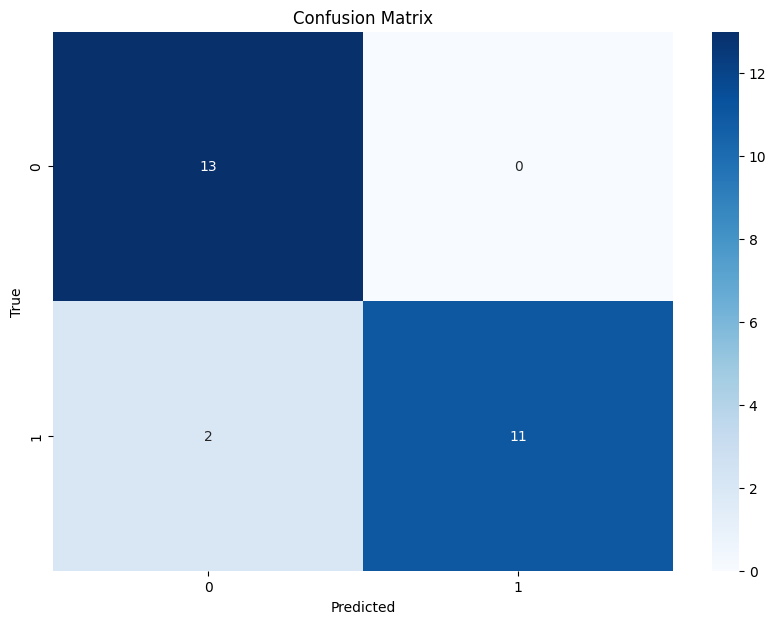

In [34]:
conf_matrix = confusion_matrix(y_test_full, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [35]:
print(classification_report(y_test_full, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8667    1.0000    0.9286        13
           1     1.0000    0.8462    0.9167        13

    accuracy                         0.9231        26
   macro avg     0.9333    0.9231    0.9226        26
weighted avg     0.9333    0.9231    0.9226        26



# CATBOOST

## Short

In [36]:
X_train_resampled = temp_train_resampled_short
X_test_short = temp_test_short
y_train_resampled = temp_train_resampled_short_labels
y_test_short = temp_test_short_labels

In [37]:
#catboost
catboost_model = CatBoostClassifier(verbose = 0, random_state=42)

param_grid = {
    'iterations': [30, 50],
    'learning_rate': [0.005, 0.01],
    'depth': [2, 3],
    'l2_leaf_reg': [5, 7, 10]
}

grid_search = GridSearchCV(
    catboost_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_short)
accuracy = accuracy_score(y_test_short, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")



Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'depth': 3, 'iterations': 50, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
Best cross-validation score: 0.8641
Test accuracy: 0.8667


In [38]:
joblib.dump(best_model, 'best_catboost_short.pkl')

['best_catboost_short.pkl']

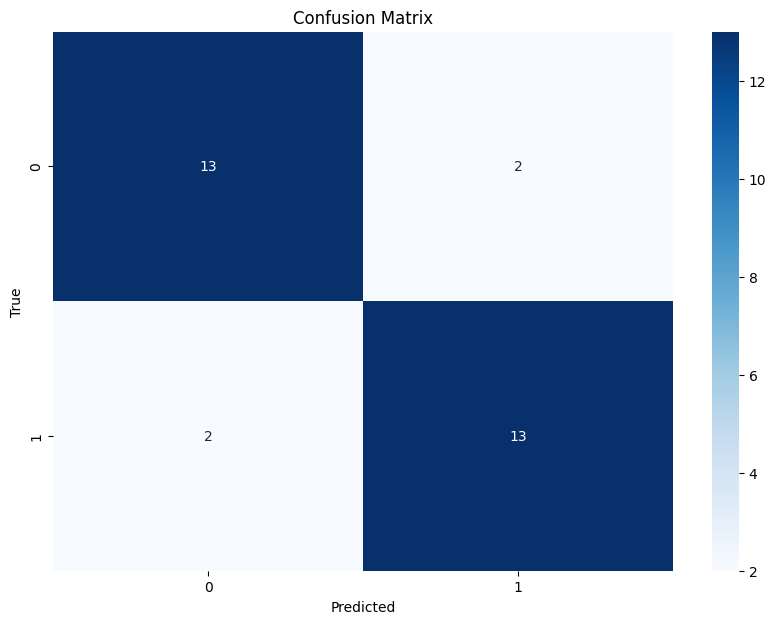

In [39]:
conf_matrix = confusion_matrix(y_test_short, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [40]:
print(classification_report(y_test_short, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8667    0.8667    0.8667        15
           1     0.8667    0.8667    0.8667        15

    accuracy                         0.8667        30
   macro avg     0.8667    0.8667    0.8667        30
weighted avg     0.8667    0.8667    0.8667        30



### long

In [41]:

X_train_resampled =temp_train_resampled_long
X_test_long = temp_test_long
y_train_resampled = temp_train_resampled_long_labels
y_test_long = temp_test_long_labels

In [42]:
#catboost
catboost_model = CatBoostClassifier(verbose = 0, random_state=42)
param_grid = {
    'iterations': [30, 50],
    'learning_rate': [0.005, 0.01],
    'depth': [2, 3],
    'l2_leaf_reg': [5, 7, 10]
}

grid_search = GridSearchCV(
    catboost_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_long)
accuracy = accuracy_score(y_test_long, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'depth': 3, 'iterations': 50, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
Best cross-validation score: 0.8722
Test accuracy: 0.9000


In [43]:
joblib.dump(best_model, 'best_catboost_long.pkl')

['best_catboost_long.pkl']

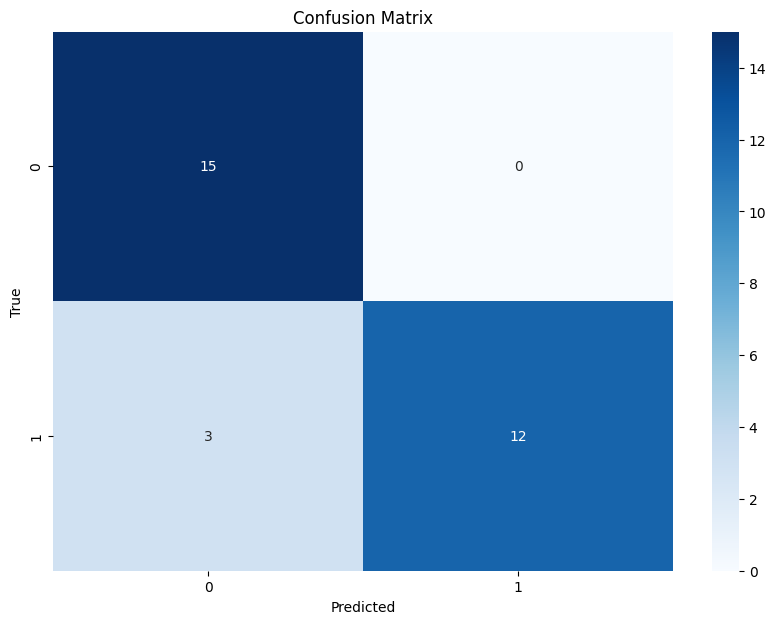

In [44]:
conf_matrix = confusion_matrix(y_test_long, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [45]:
print(classification_report(y_test_long, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8333    1.0000    0.9091        15
           1     1.0000    0.8000    0.8889        15

    accuracy                         0.9000        30
   macro avg     0.9167    0.9000    0.8990        30
weighted avg     0.9167    0.9000    0.8990        30



# full

In [46]:

X_train_resampled = temp_train_resampled_full
X_test_full = temp_test_full
y_train_resampled = temp_train_resampled_full_labels
y_test_full = temp_test_full_labels

In [47]:
#catboost
catboost_model = CatBoostClassifier(verbose = 0, random_state=42)
param_grid = {
    'iterations': [30, 50],
    'learning_rate': [0.005, 0.01],
    'depth': [2, 3],
    'l2_leaf_reg': [5, 7, 10]
}

grid_search = GridSearchCV(
    catboost_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_full)
accuracy = accuracy_score(y_test_full, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'depth': 3, 'iterations': 50, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
Best cross-validation score: 0.9412
Test accuracy: 0.8846


In [48]:
joblib.dump(best_model, 'best_catboost_full.pkl')

['best_catboost_full.pkl']

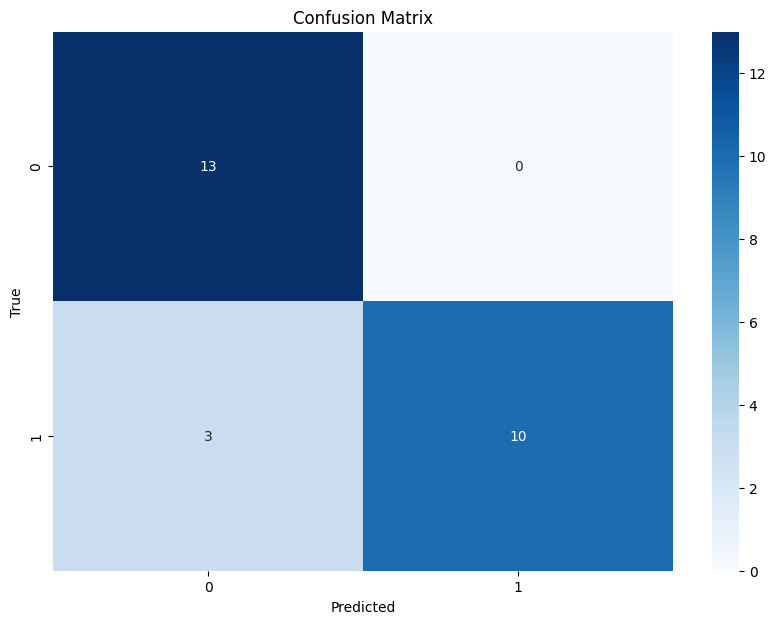

In [49]:
conf_matrix = confusion_matrix(y_test_full, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [50]:
print(classification_report(y_test_full, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8125    1.0000    0.8966        13
           1     1.0000    0.7692    0.8696        13

    accuracy                         0.8846        26
   macro avg     0.9062    0.8846    0.8831        26
weighted avg     0.9062    0.8846    0.8831        26



# XGBOOST

# short

In [51]:
X_train_resampled = temp_train_resampled_short
X_test_short = temp_test_short
y_train_resampled = temp_train_resampled_short_labels
y_test_short = temp_test_short_labels

In [52]:
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'iterations': [30, 50],
    'learning_rate': [0.005, 0.01],
    'depth': [2, 3],
    'l2_leaf_reg': [5, 7, 10]
}

grid_search = GridSearchCV(
    xgboost_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_short)
accuracy = accuracy_score(y_test_short, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")



Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'depth': 2, 'iterations': 30, 'l2_leaf_reg': 5, 'learning_rate': 0.005}
Best cross-validation score: 0.8897
Test accuracy: 0.9000


c:\Users\sefat\durus\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:53:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "depth", "iterations", "l2_leaf_reg", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [53]:
joblib.dump(best_model, 'best_xgboost_short.pkl')

['best_xgboost_short.pkl']

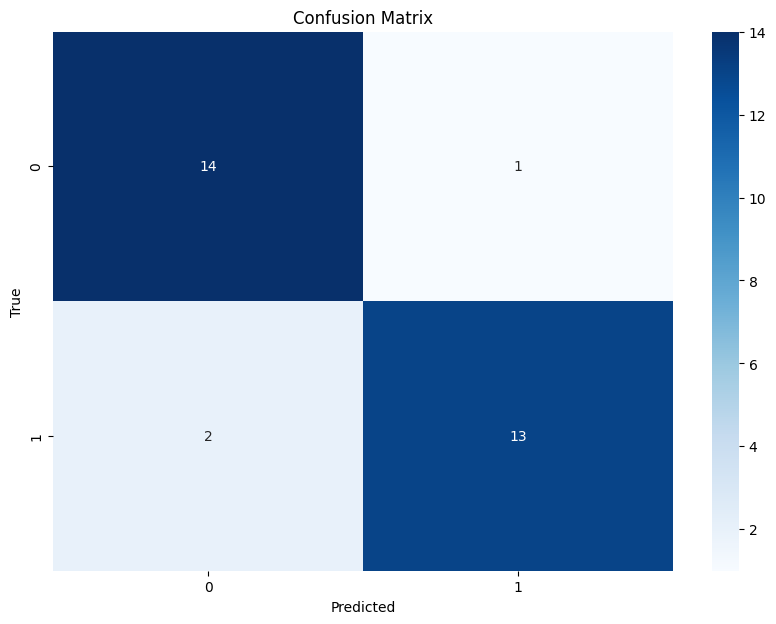

In [54]:
conf_matrix = confusion_matrix(y_test_short, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [55]:
print(classification_report(y_test_short, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.8750    0.9333    0.9032        15
           1     0.9286    0.8667    0.8966        15

    accuracy                         0.9000        30
   macro avg     0.9018    0.9000    0.8999        30
weighted avg     0.9018    0.9000    0.8999        30



## Long

In [56]:
X_train_resampled =temp_train_resampled_long
X_test_long = temp_test_long
y_train_resampled = temp_train_resampled_long_labels
y_test_long = temp_test_long_labels

In [57]:
# XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Parametre grid'i
param_grid = {
    'n_estimators': [30, 50],          
    'learning_rate': [0.005, 0.01],
    'max_depth': [2, 3],              
    'reg_lambda': [1, 3, 5, 7]               
}

# Grid Search
grid_search = GridSearchCV(
    xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Modeli eğit
grid_search.fit(X_train_resampled, y_train_resampled)

# Sonuçları yazdır
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# En iyi model ile test setinde değerlendirme
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_long)
accuracy = accuracy_score(y_test_long, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
{'learning_rate': 0.005, 'max_depth': 3, 'n_estimators': 30, 'reg_lambda': 1}
Best cross-validation score: 0.9152
Test accuracy: 0.7333


c:\Users\sefat\durus\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:53:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [58]:
joblib.dump(best_model, 'best_xgboost_long.pkl')

['best_xgboost_long.pkl']

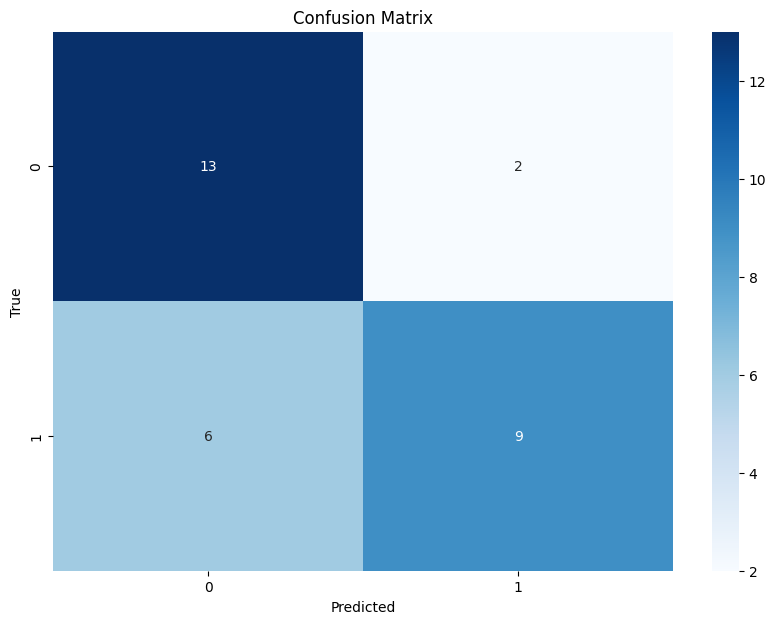

In [59]:
conf_matrix = confusion_matrix(y_test_long, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [60]:
print(classification_report(y_test_long, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.6842    0.8667    0.7647        15
           1     0.8182    0.6000    0.6923        15

    accuracy                         0.7333        30
   macro avg     0.7512    0.7333    0.7285        30
weighted avg     0.7512    0.7333    0.7285        30



## full

In [61]:
X_train_resampled = temp_train_resampled_full
X_test_full = temp_test_full
y_train_resampled = temp_train_resampled_full_labels
y_test_full = temp_test_full_labels

In [62]:
# XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [30, 50],          
    'learning_rate': [0.005, 0.01],
    'max_depth': [2, 3],              
    'reg_lambda': [1, 3, 5, 7]               
}

# Grid Search
grid_search = GridSearchCV(
    xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_full)
accuracy = accuracy_score(y_test_full, y_pred_test)
print(f"Test accuracy: {accuracy:.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 30, 'reg_lambda': 3}
Best cross-validation score: 0.8922
Test accuracy: 0.9615


c:\Users\sefat\durus\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:53:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [63]:
joblib.dump(best_model, 'best_xgboost_full.pkl')

['best_xgboost_full.pkl']

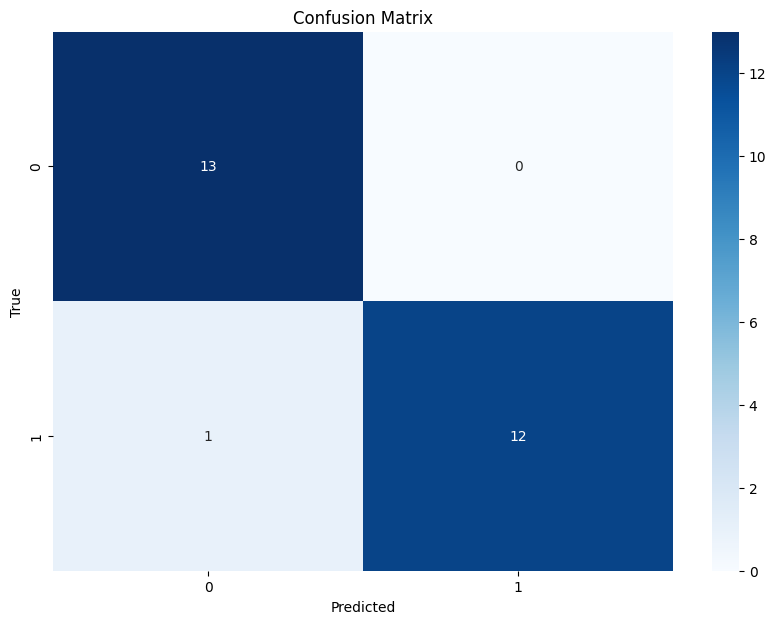

In [64]:
conf_matrix = confusion_matrix(y_test_full, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [65]:
print(classification_report(y_test_full, y_pred_test, target_names=['0', '1'], digits=4))

              precision    recall  f1-score   support

           0     0.9286    1.0000    0.9630        13
           1     1.0000    0.9231    0.9600        13

    accuracy                         0.9615        26
   macro avg     0.9643    0.9615    0.9615        26
weighted avg     0.9643    0.9615    0.9615        26

